# CP2 Dataset Exploration — PhiUSIIL Phishing URL Dataset

**Author:** Cheah Qi Yang (22095483)
**Date:** April 2026
**Purpose:** Understand PhiUSIIL structure before writing feature extractors

## Critical Rule
Use only `URL` and `label` columns. Ignore the 54 pre-extracted features —
the CP2 contribution is writing 24 feature extractors from scratch.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse

# Display settings
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')

print("Imports successful")

Imports successful


## 1. Load Dataset

In [3]:
df = pd.read_csv('../data/PhiUSIIL_Phishing_URL_Dataset.csv')
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.head()

Shape: (235795, 56)
Memory usage: 175.16 MB


,FILENAME,URL,URLLength,Domain,DomainLength,...,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,...,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,...,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,...,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,...,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,...,34,72,1,85,1


## 2. Verify URL and Label Columns

In [4]:
# Per CP2 critical rule: only use URL and label columns
print("=== URL Column ===")
print(f"Data type: {df['URL'].dtype}")
print(f"Null count: {df['URL'].isnull().sum()}")
print(f"Empty strings: {(df['URL'] == '').sum()}")
print(f"Duplicates: {df['URL'].duplicated().sum()}")

print("\n=== Label Column ===")
print(f"Data type: {df['label'].dtype}")
print(f"Null count: {df['label'].isnull().sum()}")
print(f"Unique values: {df['label'].unique()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nPercentage:")
print(df['label'].value_counts(normalize=True).round(4) * 100)

=== URL Column ===
Data type: object
Null count: 0
Empty strings: 0
Duplicates: 425

=== Label Column ===
Data type: int64
Null count: 0
Unique values: [1 0]

Label distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Percentage:
label
1    57.19
0    42.81
Name: proportion, dtype: float64


## 3. Inspect Sample URLs from Each Class

In [5]:
np.random.seed(42)  # reproducibility

print("=== 10 RANDOM LEGITIMATE URLs (label=1) ===")
legitimate_sample = df[df['label'] == 1]['URL'].sample(10, random_state=42)
for i, url in enumerate(legitimate_sample, 1):
    print(f"{i:2d}. {url[:120]}")

print("\n=== 10 RANDOM PHISHING URLs (label=0) ===")
phishing_sample = df[df['label'] == 0]['URL'].sample(10, random_state=42)
for i, url in enumerate(phishing_sample, 1):
    print(f"{i:2d}. {url[:120]}")

=== 10 RANDOM LEGITIMATE URLs (label=1) ===
 1. https://www.atelierozmoz.be
 2. https://www.diemon.com
 3. https://www.wausauschools.org
 4. https://www.paademode.com
 5. https://www.boxturtles.com
 6. https://www.mmstadium.com
 7. https://www.brswimwear.com
 8. https://www.leathercouncil.org
 9. https://www.historync.org
10. https://www.toshin.com

=== 10 RANDOM PHISHING URLs (label=0) ===
 1. http://www.soeme.com
 2. http://www.v2cde1b0d66c767a23cfb34c14552836d3.ws
 3. https://locateme.co.nz/wp-content/jam/ichiemagiksouthwest123.html
 4. http://www.kwan078lj.web.app
 5. https://jumptruegallery.000webhostapp.com/download-documents
 6. https://www.jcb.dotcombinations.com/
 7. https://www.1000bottlesparty.com/jp
 8. http://www.artzvuk.by
 9. https://leszek.arekhasnik.pl/add/email@example.com
10. https://193-42-33-145.cprapid.com/


## 4. URL Length Distribution

=== URL Length Statistics ===
          count   mean    std   min   25%   50%   75%     max
label                                                        
0      100945.0  46.24  61.07  14.0  26.0  34.0  48.0  6097.0
1      134850.0  27.23   4.82  16.0  24.0  27.0  30.0    58.0


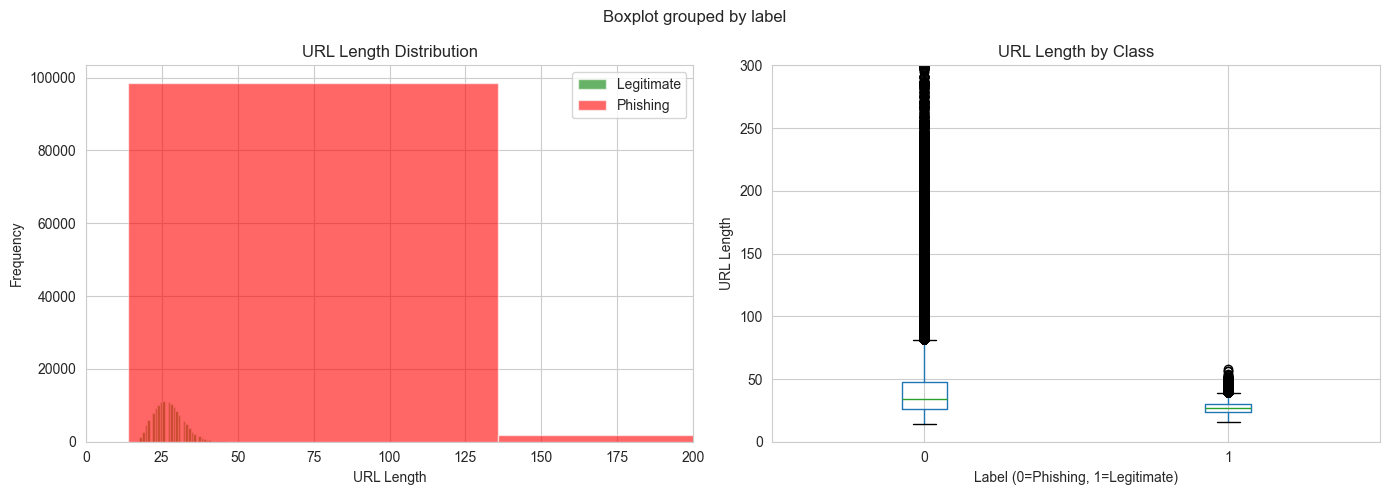

In [6]:
df['url_length'] = df['URL'].str.len()

print("=== URL Length Statistics ===")
print(df.groupby('label')['url_length'].describe().round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
df[df['label'] == 1]['url_length'].hist(bins=50, alpha=0.6, label='Legitimate', ax=axes[0], color='green')
df[df['label'] == 0]['url_length'].hist(bins=50, alpha=0.6, label='Phishing', ax=axes[0], color='red')
axes[0].set_xlabel('URL Length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('URL Length Distribution')
axes[0].set_xlim(0, 200)  # zoom in
axes[0].legend()

# Boxplot
df.boxplot(column='url_length', by='label', ax=axes[1])
axes[1].set_title('URL Length by Class')
axes[1].set_xlabel('Label (0=Phishing, 1=Legitimate)')
axes[1].set_ylabel('URL Length')
axes[1].set_ylim(0, 300)  # zoom in

plt.tight_layout()
plt.show()

## 5. URL Length Outliers — The Extreme Cases

In [7]:
# Top 5 longest URLs in each class
print("=== TOP 5 LONGEST PHISHING URLs ===")
top_phishing = df[df['label'] == 0].nlargest(5, 'url_length')[['URL', 'url_length']]
for _, row in top_phishing.iterrows():
    print(f"\nLength: {row['url_length']}")
    print(f"URL: {row['URL'][:200]}...")  # truncated to 200 chars

print("\n\n=== TOP 5 LONGEST LEGITIMATE URLs ===")
top_legit = df[df['label'] == 1].nlargest(5, 'url_length')[['URL', 'url_length']]
for _, row in top_legit.iterrows():
    print(f"\nLength: {row['url_length']}")
    print(f"URL: {row['URL']}")  # show full

=== TOP 5 LONGEST PHISHING URLs ===

Length: 6097
URL: https://xwebhostapp.github.io/freehost//#eyj2zxjzaw9uijoimc4yljailcjjb21wcmvzc2vkijpmywxzzswiym9kesi6ilxupcfet0nuwvbfigh0bww+xg48agvhzd5cbjxzdhlszt5cbioge1xuxhrib3gtc2l6aw5noibib3jkzxitym94o1xufvxuxg5...

Length: 5795
URL: https://b4e921f0.sso-mailsrvr-4344e5teed.pages.dev/support/?emailtoken=abuse@gmail.com&amp;domain=gmail.com#eyj2zxjzaw9uijoimc4yljailcjjb21wcmvzc2vkijpmywxzzswiym9kesi6ilxupcfet0nuwvbfigh0bww+xg48agvh...

Length: 4274
URL: https://bodhicardstech.com/beta/wx%20qz%20xx%20ww%20qxz%20wes%20wsed/54dr%2056yg%2065yft5%204f6yft5%20d46yg5%20fyt45t%20f4d4%20yf56td4/ft5%20fy%2065y%204%205tdr34%204yf46%20y5uyf%20t5%20d6yf5%20td%204...

Length: 4247
URL: https://inspirationalatmospheres.com/qxzrrr%20rrqw%20xzaq%20eew/4r3e7%20g6y5%2065yf%2065f%2045ft%207ugy%20456%205y7ug5%204ft%20457ug5%2045ft45t%2056g564%207hu6y6%205ft4t/6y5%207ug6y%207u5g%2056u7%20g5...

Length: 4054
URL: https://bodhicardstech.com/beta/wx%20qz%20xx%20ww%20q

## 6. Character Distribution Analysis

Phishing URLs often have unusual character compositions:
- High digit ratio (random IPs, hex domains)
- Many special characters (encoded payloads, parameter stuffing)
- Low alpha ratio (less readable text)

In [8]:
def compute_char_stats(url):
    """Compute character composition stats for one URL."""
    if not url or not isinstance(url, str):
        return {'digit_ratio': 0, 'alpha_ratio': 0, 'special_ratio': 0}
    total = len(url)
    digits = sum(c.isdigit() for c in url)
    alphas = sum(c.isalpha() for c in url)
    specials = total - digits - alphas
    return {
        'digit_ratio': digits / total,
        'alpha_ratio': alphas / total,
        'special_ratio': specials / total
    }

# Apply to all URLs (takes ~30 seconds)
print("Computing character stats for 235k URLs...")
char_stats = df['URL'].apply(compute_char_stats).apply(pd.Series)
df = pd.concat([df, char_stats], axis=1)
print("Done.")

# Compare by class
print("\n=== Character Ratios by Class ===")
print(df.groupby('label')[['digit_ratio', 'alpha_ratio', 'special_ratio']].mean().round(4))

Computing character stats for 235k URLs...
Done.

=== Character Ratios by Class ===
       digit_ratio  alpha_ratio  special_ratio
label                                         
0           0.0636       0.7472         0.1892
1           0.0020       0.8000         0.1980


## 7. TLD (Top-Level Domain) Analysis

Identify which TLDs dominate phishing vs legitimate URLs.
This informs the `tld_risk_score` feature (CP2 feature #24, MITRE T1583.001).

In [9]:
import tldextract

def get_tld(url):
    """Extract TLD using tldextract for accuracy."""
    try:
        return tldextract.extract(url).suffix
    except Exception:
        return ''

# Apply to all URLs (takes ~60 seconds, slower than char stats)
print("Extracting TLDs from 235k URLs...")
df['tld'] = df['URL'].apply(get_tld)
print("Done.")

# Top 15 TLDs in each class
print("\n=== TOP 15 TLDs in PHISHING URLs (label=0) ===")
phishing_tlds = df[df['label'] == 0]['tld'].value_counts().head(15)
print(phishing_tlds)

print("\n=== TOP 15 TLDs in LEGITIMATE URLs (label=1) ===")
legit_tlds = df[df['label'] == 1]['tld'].value_counts().head(15)
print(legit_tlds)

# Phishing-dominant TLDs (where phishing % > 50%)
print("\n=== TLDs MOST DOMINATED BY PHISHING (suspicious TLDs) ===")
tld_distribution = df.groupby('tld')['label'].agg(['count', 'mean']).round(4)
tld_distribution.columns = ['total_count', 'legit_proportion']
tld_distribution['phishing_proportion'] = 1 - tld_distribution['legit_proportion']
# Filter to TLDs with at least 100 URLs to avoid noise
suspicious = tld_distribution[
    (tld_distribution['total_count'] >= 100) &
    (tld_distribution['phishing_proportion'] >= 0.7)
].sort_values('phishing_proportion', ascending=False).head(20)
print(suspicious)

Extracting TLDs from 235k URLs...
Done.

=== TOP 15 TLDs in PHISHING URLs (label=0) ===
tld
com     43780
app      6368
co       4918
io       3769
net      3099
ru       2983
top      2327
dev      2312
org      2269
site     1477
link     1455
xyz      1448
cf       1203
ga       1107
ml        994
Name: count, dtype: int64

=== TOP 15 TLDs in LEGITIMATE URLs (label=1) ===
tld
com       68785
org       16524
net        3998
co.uk      3807
de         3310
edu        1856
it         1577
com.au     1574
nl         1536
ca         1356
org.uk     1343
fr         1336
gov        1276
com.br      950
ru          892
Name: count, dtype: int64

=== TLDs MOST DOMINATED BY PHISHING (suspicious TLDs) ===
       total_count  legit_proportion  phishing_proportion
tld                                                      
               608            0.0000               1.0000
cf            1203            0.0000               1.0000
cfd            107            0.0000               1.0000
pag

## 8. HTTPS vs HTTP Distribution

Check the `has_https` feature signal strength.
Modern phishing increasingly uses HTTPS (free Let's Encrypt certs),
so this feature may be weaker than 5 years ago.

=== HTTPS Distribution ===
       HTTP only (%)  HTTPS (%)
label                          
0              51.26      48.74
1               0.00     100.00

=== HTTPS Adoption by Class ===
Legitimate URLs using HTTPS: 100.00%
Phishing URLs using HTTPS:   48.74%


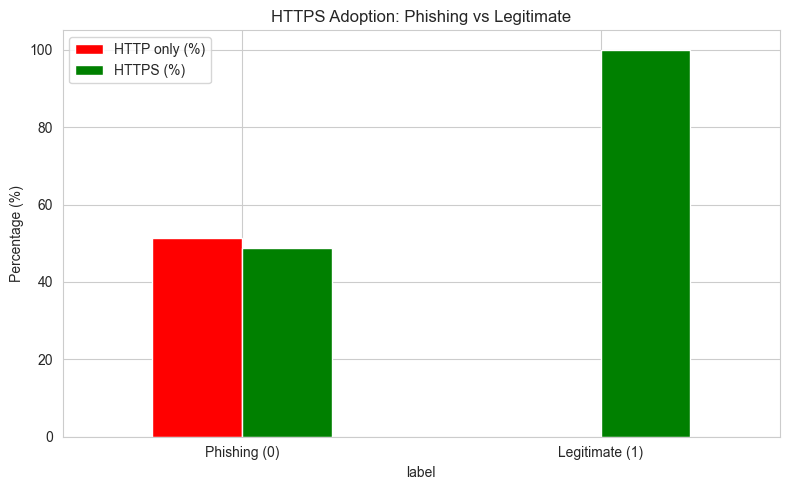

In [10]:
df['has_https'] = df['URL'].str.startswith('https://').astype(int)

print("=== HTTPS Distribution ===")
crosstab = pd.crosstab(df['label'], df['has_https'], normalize='index').round(4) * 100
crosstab.columns = ['HTTP only (%)', 'HTTPS (%)']
print(crosstab)

print("\n=== HTTPS Adoption by Class ===")
print(f"Legitimate URLs using HTTPS: {df[df['label']==1]['has_https'].mean()*100:.2f}%")
print(f"Phishing URLs using HTTPS:   {df[df['label']==0]['has_https'].mean()*100:.2f}%")

# Quick visualization
fig, ax = plt.subplots(figsize=(8, 5))
crosstab.plot(kind='bar', ax=ax, color=['red', 'green'], stacked=False)
ax.set_xticklabels(['Phishing (0)', 'Legitimate (1)'], rotation=0)
ax.set_ylabel('Percentage (%)')
ax.set_title('HTTPS Adoption: Phishing vs Legitimate')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Domain Length and Subdomain Patterns

Analyze domain structure to validate `domain_length` and detect AiTM
nesting patterns (e.g., `secure.login.paypal.evil.com` — multiple subdomains).

In [11]:
def parse_domain_components(url):
    """Extract domain length and subdomain count."""
    try:
        ext = tldextract.extract(url)
        # Full registered domain (e.g., "paypal.com")
        registered = f"{ext.domain}.{ext.suffix}" if ext.suffix else ext.domain
        # Subdomain count (e.g., "secure.login" = 2)
        subdomain_count = len(ext.subdomain.split('.')) if ext.subdomain else 0
        return {
            'domain_length': len(ext.domain),
            'subdomain_count': subdomain_count,
            'has_subdomain': 1 if subdomain_count > 0 else 0
        }
    except Exception:
        return {'domain_length': 0, 'subdomain_count': 0, 'has_subdomain': 0}

print("Parsing domains for 235k URLs...")
domain_stats = df['URL'].apply(parse_domain_components).apply(pd.Series)
df = pd.concat([df, domain_stats], axis=1)
print("Done.")

print("\n=== Domain Statistics by Class ===")
print(df.groupby('label')[['domain_length', 'subdomain_count']].describe().round(2))

print("\n=== Subdomain Count Distribution ===")
subdomain_dist = pd.crosstab(df['label'], df['subdomain_count'], normalize='index').round(4) * 100
print(subdomain_dist)

Parsing domains for 235k URLs...
Done.

=== Domain Statistics by Class ===
      domain_length                         ... subdomain_count                     
              count   mean   std  min  25%  ...             min  25%  50%  75%   max
label                                       ...                                     
0          100945.0   8.98  4.89  1.0  6.0  ...             0.0  1.0  1.0  1.0  10.0
1          134850.0  10.83  4.83  1.0  7.0  ...             0.0  1.0  1.0  1.0   4.0

[2 rows x 16 columns]

=== Subdomain Count Distribution ===
subdomain_count     0      1      2     3     4     5     6     7    8    10
label                                                                       
0                15.51  63.93  15.62  3.13  1.47  0.32  0.02  0.01  0.0  0.0
1                 0.02  97.10   2.71  0.17  0.00  0.00  0.00  0.00  0.0  0.0


## 10. Save Findings Summary

Persist key findings as a JSON for thesis Section 3.4 reference.
This locks the empirical evidence used in feature engineering decisions.

In [13]:
import json
from datetime import datetime

findings = {
    "exploration_date": datetime.now().strftime("%Y-%m-%d"),
    "dataset": "PhiUSIIL Phishing URL Dataset",
    "total_rows": int(len(df)),
    "total_columns_in_source": 56,
    "columns_used": ["URL", "label"],
    "label_encoding": {
        "0": "phishing",
        "1": "legitimate"
    },
    "class_distribution": {
        "phishing_count": int((df['label'] == 0).sum()),
        "legitimate_count": int((df['label'] == 1).sum()),
        "phishing_pct": round((df['label'] == 0).mean() * 100, 2),
        "legitimate_pct": round((df['label'] == 1).mean() * 100, 2)
    },
    "duplicates": int(df['URL'].duplicated().sum()),
    "url_length_stats": {
        "phishing_mean": round(df[df['label']==0]['url_length'].mean(), 2),
        "phishing_max": int(df[df['label']==0]['url_length'].max()),
        "legitimate_mean": round(df[df['label']==1]['url_length'].mean(), 2),
        "legitimate_max": int(df[df['label']==1]['url_length'].max())
    },
    "https_adoption": {
        "phishing_pct": round(df[df['label']==0]['has_https'].mean() * 100, 2),
        "legitimate_pct": round(df[df['label']==1]['has_https'].mean() * 100, 2)
    },
    "char_ratios": {
        "phishing": {
            "digit_ratio": round(df[df['label']==0]['digit_ratio'].mean(), 4),
            "alpha_ratio": round(df[df['label']==0]['alpha_ratio'].mean(), 4)
        },
        "legitimate": {
            "digit_ratio": round(df[df['label']==1]['digit_ratio'].mean(), 4),
            "alpha_ratio": round(df[df['label']==1]['alpha_ratio'].mean(), 4)
        }
    },
    "subdomain_patterns": {
        "phishing_zero_subdomain_pct": round((df[df['label']==0]['subdomain_count']==0).mean()*100, 2),
        "legitimate_zero_subdomain_pct": round((df[df['label']==1]['subdomain_count']==0).mean()*100, 2),
        "phishing_max_subdomains": int(df[df['label']==0]['subdomain_count'].max()),
        "legitimate_max_subdomains": int(df[df['label']==1]['subdomain_count'].max())
    },
    "high_risk_tlds_100pct_phishing": ["cf", "ml", "gq", "icu", "page", "cfd"],
    "limitations_documented": [
        "Legitimate URLs are homepage-only (max 58 chars)",
        "100% legitimate use HTTPS (real-world ~95-97%)",
        "Several TLDs show 100% phishing concentration (collection bias)",
        "Mitigation: hybrid architecture + PhishTank holdout + external TLD risk data"
    ]
}

# Save to reports folder
output_path = '../reports/week1_exploration_findings.json'
with open(output_path, 'w') as f:
    json.dump(findings, f, indent=2)

print(f"Findings saved to: {output_path}")
print("\n=== Summary ===")
print(json.dumps(findings, indent=2))

Findings saved to: ../reports/week1_exploration_findings.json

=== Summary ===
{
  "exploration_date": "2026-05-04",
  "dataset": "PhiUSIIL Phishing URL Dataset",
  "total_rows": 235795,
  "total_columns_in_source": 56,
  "columns_used": [
    "URL",
    "label"
  ],
  "label_encoding": {
    "0": "phishing",
    "1": "legitimate"
  },
  "class_distribution": {
    "phishing_count": 100945,
    "legitimate_count": 134850,
    "phishing_pct": 42.81,
    "legitimate_pct": 57.19
  },
  "duplicates": 425,
  "url_length_stats": {
    "phishing_mean": 46.24,
    "phishing_max": 6097,
    "legitimate_mean": 27.23,
    "legitimate_max": 58
  },
  "https_adoption": {
    "phishing_pct": 48.74,
    "legitimate_pct": 100.0
  },
  "char_ratios": {
    "phishing": {
      "digit_ratio": 0.0636,
      "alpha_ratio": 0.7472
    },
    "legitimate": {
      "digit_ratio": 0.002,
      "alpha_ratio": 0.8
    }
  },
  "subdomain_patterns": {
    "phishing_zero_subdomain_pct": 15.51,
    "legitimate_zero